**Coursebook: Regression Model**

- Part of Data Science in Python Specialization for PT Freeport Indonesia
- Course Length: 9 Hours
- Last Updated: September 2025

___

- Developed by [Algoritma](https://algorit.ma)'s product division and instructors team

# Background

The coursebook is part of the **Comprehensive Data Science and Machine Learning Program** prepared by Algoritma. The coursebook is intended for a restricted audience only, i.e. the individuals and organizations having received this coursebook directly from the training organization. It may not be reproduced, distributed, translated or adapted in any form outside these individuals and organizations without permission. 

Algoritma is a data science education center based in Jakarta. We organize workshops and training programs to help working professionals and students gain mastery in various data science sub-fields: data visualization, machine learning, data modeling, statistical inference etc.

## Training Objectives

We will start by learning about what is machine learning in general and learn about your first regression model. This coursebook is intended for participants who have completed the preceding courses.

In this coursebook we will cover:

- **Data Preparation & Exploratory Data**
	- Data types inspection & preparation
	- Correlation and distribution from several variables
	- Statistics summary
- **Data Pre-Processing**
	- Target & predictors splitting
	- Dummy Variables for Categorical Predictor
		- One Hot Encoding
		- Dummy Variables
- **Model Linear**
	- Model Construction 
	- Simple Linear Regression
	- Multiple Linear Regression
	- Plotting Regression 
- **Interpreting Linear Models**
	- Understanding Coefficients
	- Estimates and standard error 
	- Confidence interval 
- **Model Assumptions and Evaluation**
	- Model evaluation
		- R-squared & Adjusted r-squared 
		- Error
	- Model assumptions 
		- Normality of Residuals
		- Homoscedasticity
		- No Multicollinearity
- **Model Implementation**
	- Model Forecasting

Before going into our main topic for this coursebook, let's import the packages we are going to use:

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# suppress scientific notation
np.set_printoptions(suppress=True) # numpy output
pd.set_option('display.float_format', lambda x: '%.2f' % x) # pandas output

# suppress warning
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

# Introduction to Machine Learning

Machine learning on a very basic level, refers to a sub-field of computer science that “gives computer the ability to learn without being explicitly programmed”. Less-sensationally, it is concerned with the theory and application of statistical and mathematical methods to arrive at a particular objective without following a set of strictly defined and rigid pre-determined rules.

The most common machine learning is divided into two types, namely **supervised learning** and **unsupervised learning**. The difference between the two is that when we talk about **supervised learning** then we talk about predictions of a value because in supervised learning the data we will analyze has a variable target.

When the prediction value is numerical (think oil prices, rainfall, quarterly sales, blood pressure etc), it is generally referred to as a “regression” problem. This is in contrast with “classification” problems, a general term for when the value we’re trying to predict is categorical (loan defaults, email spam collection, handwriting recognition etc).

Whereas if we talk about **unsupervised learning** then we talk about data exploration because the data we want to process doesn't have a variable target. The method usually used to analyze a data using unsupervised learning is clustering or data grouping.

## Introduction to Regression Model

First of all we want to learn about machine learning is about regression model. So let’s try and achieve some intuition about this important concept through the following illustration. I’m going to ahead and load some data and create a histogram from the resulting data.

It is important here to remind you that regression models are not just used in the machine learning context for numeric prediction. Regression, in fact, represent the “workhorse of data science” and is among the most practical and theoretically understood models in statistics. Data scientists well trained with this foundation will be able “to solve an incredible array of problems”. Because regression models often lead to highly interpretable models, we can (and should) consider them as a handy statistical tool that has its place in some of the most common data science tasks:

- **Prediction**: Predict the profitability of a new product category given its pilot launch sales figure
- **Statistical Modeling**: Determining a quantitative relationship between price sensitivity and average sales unit
- **Covariation**: Determining the (residual) variation in average sales unit that appears unrelated to price levels; and to investigate the impact of other external factors beyond price points in explaining the fluctuation of average sales unit

# Study Case: Prediction of Oil Production on Volve Field Production Data

The Volve Field was an offshore oil field located in the North Sea, off the coast of Norway. The field was operated by Equinor, one of the major oil companies in Norway. Volve Field production commenced in February 2008 and it was officially shut down in September 2016. In 2018, Equinor released a dataset from the Volve Field that includes geological, operational, production, and technical data. This dataset offer valuable insights into the daily workings of an oil field, providing an opportunity for analytical studies in the oil and gas industry. 

Using the Volve Field dataset, we aim to predict daily oil production volumes based on the operational and physical parameters provided in the dataset. By predicting future oil production, oil and gas industries can enhance their operational efficiency, economic performance, and environmental sustainability. 

## Data Preparation

Data preparation is the initial step after we formulate the right business question. The main objective of this process is to ensure data suitability. That is, we aim to work with data in the correct format.

First, let's read our Volve Field Production data from the `volve_field.csv` in the `data_input` folder.

In [140]:
volve = pd.read_csv('data_input/volve_field.csv')
volve.head()

,DATE_PERIOD,NPD_WELL_BORE_NAME,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,BORE_OIL_VOL
0,2008-03-21,15/9-F-12,24.00,274.07,105.92,174.50,6.70,32.09,99.57,75.36,3192.00
1,2008-03-22,15/9-F-12,24.00,273.46,105.92,174.28,6.46,32.08,99.17,75.32,3172.00
2,2008-03-23,15/9-F-12,24.00,272.88,105.91,174.09,6.29,32.06,98.79,75.35,3160.00
3,2008-03-24,15/9-F-12,24.00,272.24,105.91,173.84,4.96,32.13,98.40,74.81,3153.00
4,2008-03-25,15/9-F-12,24.00,271.68,105.91,173.64,14.91,32.04,98.04,74.96,3131.00


Here is an explanation of each column from the Volve Field dataset:

- `DATE_PERIOD`: The date on which the production data was recorded.
- `NPD_WELL_BORE_NAME`: The name of the wellbore.
- `ON_STREAM_HRS`: The number of hours the well was actively producing during the date of the report.
- `AVG_DOWNHOLE_PRESSURE`: The average pressure (bar) inside the wellbore at the downhole location.
- `AVG_DOWNHOLE_TEMPERATURE`: The average temperature (°C) inside the wellbore at the downhole.
- `AVG_DP_TUBING`: The average pressure differential (bar) across the tubing.
- `AVG_ANNULUS_PRESS`: The average pressure (bar) in the annulus, which is the space between the casing and the tubing of the well.
- `AVG_CHOKE_SIZE_P`: The average setting of the choke valve size (in percentage), which controls the flow of fluids from the well.
- `AVG_WHP_P`: The average setting of the wellhead pressure (in percentage), which controls the pressure at the surface of the wellhead.
- `AVG_WHT_P`: The average setting of the wellhead temperature (in percentage), which controls the temperature at the surface of the wellhead.
- `BORE_OIL_VOL`: The volume of oil (barrel) produced from the wellbore during the period of report.

### Data Type Inspection

When dealing with tabular data, it is necessary to assest data type correctness for each column. Let's check our dataset's data type for each columns.

In [141]:
volve.dtypes

DATE_PERIOD                  object
NPD_WELL_BORE_NAME           object
ON_STREAM_HRS               float64
AVG_DOWNHOLE_PRESSURE       float64
AVG_DOWNHOLE_TEMPERATURE    float64
AVG_DP_TUBING               float64
AVG_ANNULUS_PRESS           float64
AVG_CHOKE_SIZE_P            float64
AVG_WHP_P                   float64
AVG_WHT_P                   float64
BORE_OIL_VOL                float64
dtype: object

Notice that the some of the columns are an object where `DATE_PERIOD` should be a `datetime` and `NPD_WELL_BORE_NAME` should be a `category`. Therefore, we need to change the data type of these columns.

In [142]:
volve['DATE_PERIOD'] = pd.to_datetime(volve['DATE_PERIOD'])
volve['NPD_WELL_BORE_NAME'] = volve['NPD_WELL_BORE_NAME'].astype('category')

volve.dtypes

DATE_PERIOD                 datetime64[ns]
NPD_WELL_BORE_NAME                category
ON_STREAM_HRS                      float64
AVG_DOWNHOLE_PRESSURE              float64
AVG_DOWNHOLE_TEMPERATURE           float64
AVG_DP_TUBING                      float64
AVG_ANNULUS_PRESS                  float64
AVG_CHOKE_SIZE_P                   float64
AVG_WHP_P                          float64
AVG_WHT_P                          float64
BORE_OIL_VOL                       float64
dtype: object

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is a crucial initial stage for understanding the characteristics of dataset. EDA helps data scientists identify patterns, trends, anomalies and relationships between variables, and select relevant features.

### Statistics Summary

Now that the data type have been corrected, we can see more detailed information in our data. The first thing we will review is the statistical description of our data.

To see descriptions of each columns in the dataset, we can use the `.describe()` method.

In [143]:
volve.describe().T

,count,mean,min,25%,50%,75%,max,std
DATE_PERIOD,4108,2013-10-22 01:53:13.378773248,2008-03-21 00:00:00,2013-02-22 18:00:00,2014-07-25 00:00:00,2015-07-27 00:00:00,2016-09-17 00:00:00,NaN
ON_STREAM_HRS,4108.00,23.20,0.50,24.00,24.00,24.00,24.00,3.14
AVG_DOWNHOLE_PRESSURE,4108.00,241.30,96.61,220.32,246.14,261.51,302.65,24.39
AVG_DOWNHOLE_TEMPERATURE,4108.00,104.12,39.55,100.45,105.95,106.48,107.51,3.73
AVG_DP_TUBING,4108.00,195.40,62.58,170.15,188.93,222.36,248.71,27.38
AVG_ANNULUS_PRESS,4108.00,18.42,0.00,14.46,19.01,22.09,30.02,5.04
AVG_CHOKE_SIZE_P,4108.00,53.84,0.76,12.29,51.14,100.00,100.00,37.24
AVG_WHP_P,4108.00,45.90,15.61,31.11,37.64,57.83,99.57,19.34
AVG_WHT_P,4108.00,71.32,7.04,62.82,80.18,87.03,92.07,20.22
BORE_OIL_VOL,4108.00,1250.27,4.00,222.00,687.50,1306.25,5889.00,1463.34


`.describe()` will return the following statistical measurements:

- `count`: the number of observations in the column.
- `mean`: the mean value.
- `min`: the minimum value.
- `25%`: the lower quartile (Q1).The value under which 25% of data points present.
- `50%`: the median (Q2). The value under which 50% of data points present.
- `75%`: the upper quartile (Q3). The value under which 75% of data points present.
- `max`: the maximum value of the respective column.
- `std`: the standard deviation. This measurement reveals the average deviation of each observation to the mean value.

Using the statistical descriptions, we can gain an overview of the distribution and central tendencies of each numerical column, which is valuable for gaining insights into the dataset and for further analysis. For example, we can measure the typical reservoir conditions, variability in daily oil production volumes, and indicate peak production days.

### Data Distribution

To examine our data distribution even further, we can create visualizations of each variable. One of the benefit of visualizing data distribution is to check whether there are outliers or not in the data. The presence of outliers or observations with very distant characteristics can affect the regression model, and it is important to consider whether to remove them or not. We will check the data distribution of the target variable using boxplots and histograms.

#### Boxplots

To create a boxplot, we can use `.plot.box()` method.

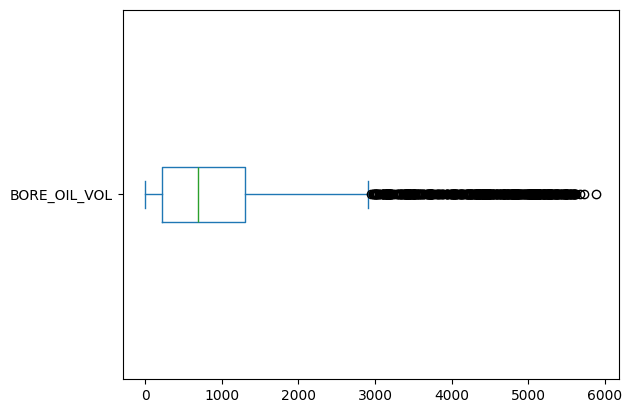

In [144]:
volve['BORE_OIL_VOL'].plot.box(vert=False);

The boxplot identifies outlier as values that are above or below the "whiskers", where the whiskers are:

$$Upper\;Whiskers = Q3 + 1.5 * IQR$$

$$Lower\;Whiskers = Q1 - 1.5 * IQR$$

where
$$
IQR = Q3 - Q1
$$

From the `BORE_OIL_VOL` column, we can see that our target variable have outliers. These outliers have potential to affect our regression, we will discuss about them in the next section.

#### Histogram

Suppose we want to see the distribution of data in detail, therefore we need a histogram. To create a histogram, we can use `.plot.hist()` method.

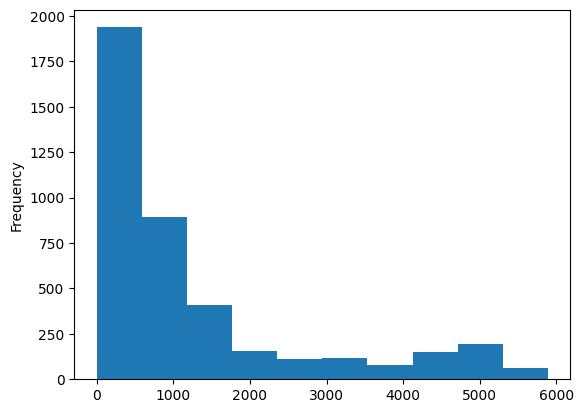

In [145]:
volve['BORE_OIL_VOL'].plot.hist();

From the histogram, we can see that our the `BORE_OIL_VOL` column is positively skewed. We can conclude that most of the time, the well produces a lower volume of oil ranging from 0-1000 barrels.

### Variable Correlation

We have discussed that regression is formed based on the linear relationship of the target variable with the predictor variable. So we will check the relationship between the variables in the data using correlation. Correlation measures the level of strength of relationship between variables with a range of -1 to 1.

- The closer the correlation value to 1 or -1, the relationship between variables is  stronger.
	- If the value is positive, then the relationship between the two variables is in the same direction. For example, variable A increases, variable B increases. 
	- If the value is negative, then the relationship between the two variables is in the opposite direction. For example, variable A increases, variable B decreases.
- The closer the correlation value is to 0, the relationship between variables is weaker.

To see correlation of variables, we can use the `.corr()` method.

In [146]:
volve.corr(numeric_only=True)

,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,BORE_OIL_VOL
ON_STREAM_HRS,1.00,-0.10,0.01,0.01,0.18,0.19,-0.14,0.11,0.12
AVG_DOWNHOLE_PRESSURE,-0.10,1.00,-0.32,0.73,0.08,0.52,0.23,0.68,0.15
AVG_DOWNHOLE_TEMPERATURE,0.01,-0.32,1.00,-0.57,-0.00,-0.55,0.41,-0.45,0.33
AVG_DP_TUBING,0.01,0.73,-0.57,1.00,0.13,0.78,-0.50,0.67,-0.30
AVG_ANNULUS_PRESS,0.18,0.08,-0.00,0.13,1.00,0.07,-0.09,0.20,-0.04
AVG_CHOKE_SIZE_P,0.19,0.52,-0.55,0.78,0.07,1.00,-0.44,0.77,0.02
AVG_WHP_P,-0.14,0.23,0.41,-0.50,-0.09,-0.44,1.00,-0.08,0.61
AVG_WHT_P,0.11,0.68,-0.45,0.67,0.20,0.77,-0.08,1.00,0.28
BORE_OIL_VOL,0.12,0.15,0.33,-0.30,-0.04,0.02,0.61,0.28,1.00


Alternatively, we can visualize correlation between variables using the `heatmap()` function from `seaborn`.

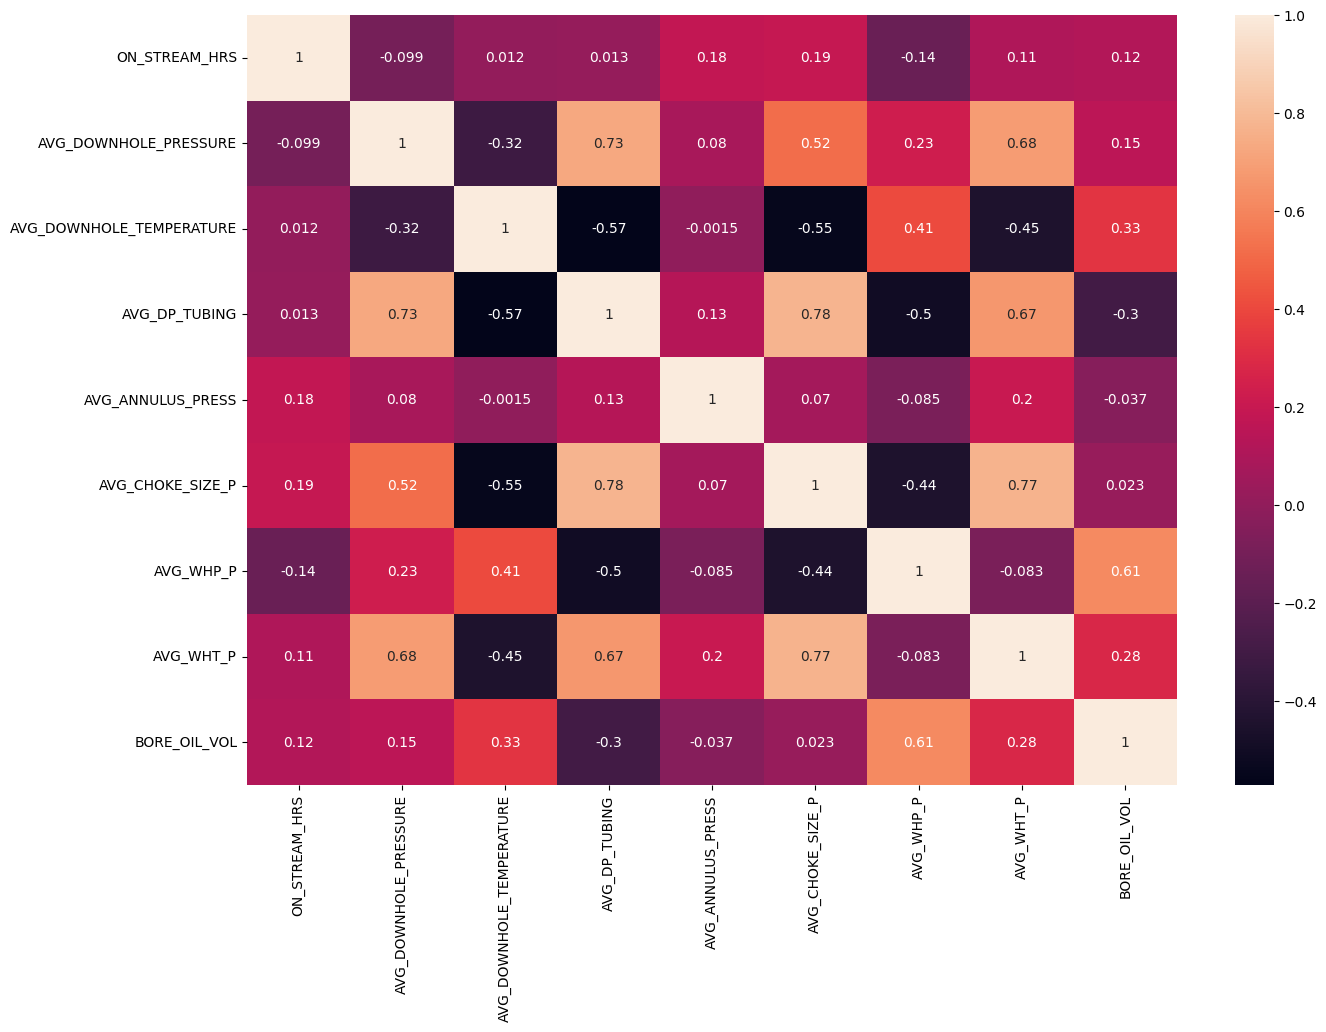

In [147]:
plt.figure(figsize = (15,10))

fig = sns.heatmap(volve.corr(numeric_only=True), annot=True)

Notice that there are a variable that have a strong correlation with our target variable (`BORE_OIL_VOL`), which is the `AVG_WHP_P` column.

## Data Preprocessing

### Check Missing Values

It is important to check for missing values in a dataset before using machine learning algorithms because missing data can have a significant impact on the performance and accuracy of the machine learning models. In addition, some machine learning algorithms do not handle missing values well and may either fail or introduce additional bias into the model. Therefore, it is important to handle missing values appropriately before applying machine learning algorithms. 

In [148]:
volve.isnull().sum()

DATE_PERIOD                 0
NPD_WELL_BORE_NAME          0
ON_STREAM_HRS               0
AVG_DOWNHOLE_PRESSURE       0
AVG_DOWNHOLE_TEMPERATURE    0
AVG_DP_TUBING               0
AVG_ANNULUS_PRESS           0
AVG_CHOKE_SIZE_P            0
AVG_WHP_P                   0
AVG_WHT_P                   0
BORE_OIL_VOL                0
dtype: int64

Thankfully, there are no missing values in our dataset. If our dataset in another project has missing values, it can be handled in several ways:

1. Delete rows with missing values
2. Replace the missing values with statistical values (e.g., average, mode for category).
3. Use the ML model to find the missing values, for example, MICE (Multiple Imputation by Chained Equation) or KNN Imputation.

### Check Duplicates Values

It is important to check for duplicate data before using machine learning because duplicates can affect the accuracy of the machine learning model. When there are duplicate records in the dataset, it can result in a biased model as the model may give more importance to these duplicate records. This is because the duplicate data inflates the sample size and therefore, the statistical analysis may overestimate the true significance of the results. Therefore, it is important to identify and remove duplicate data before training the machine learning model.

In [149]:
volve.duplicated().sum()

0

The dataset is clean enough. If our dataset in another project has duplicated values, handling duplicate values can depend on the context in which they occur, but here are several general ways to handle them:
1. Remove duplicates: One way to handle duplicates is to remove them altogether. This can be useful if we only need the unique values in a data set or if duplicates are causing issues in a program. 
2. Keep only one copy of duplicates: Another approach is to keep only one copy of each duplicate value. This can be useful if we want to preserve some information from the duplicates, such as the first or last occurrence. 

### Handle Categorical Data: Encoding

![categorical-type.png](assets/categorical-type.png)

Categorical data refers to data that is divided into groups or categories, where each observation belongs to a particular category. In machine learning, categorical data is an essential part of many datasets and can provide valuable insights into the behavior of a system or the characteristics of a group.

Categorical data can be further divided into two types: **nominal and ordinal**. **Nominal** data refers to data that is not ordered or ranked, such as gender or eye color. On the other hand, **ordinal** data refers to data that is ordered or ranked, such as education level or income bracket.

Handling categorical data in machine learning is essential as most machine learning algorithms **require numerical input data**. There are several ways to handle categorical data in machine learning, including **one-hot encoding** and **ordinal encoding**.

- **One-hot encoding** is a process of representing categorical data as binary vectors, where each category is represented by a binary digit (0 or 1) in a vector. *For example, if we have a categorical feature "color" with three possible values - red, green, and blue, one hot encoding would represent these values as [1,0,0], [0,1,0], and [0,0,1] respectively*.

- **Ordinal encoding** is another method of encoding categorical data where each category is assigned a unique numerical value where the values are assigned based on their rank or order. *For example, if we have a categorical feature "size" with three possible values - small, medium, and large, ordinal encoding would represent these values as 1, 2, and 3, respectively*.

In [150]:
volve.select_dtypes('category').columns

Index(['NPD_WELL_BORE_NAME'], dtype='object')

Since the only categorical data in our dataset is the `NPD_WELL_BORE_NAME` column, which has no order in its value, we will use One-Hot Encoding to encode the column. 

#### One-Hot Encoding

One of the ways to do one-hot encoding in Python is by using the `pd.get_dummies()` method from the Pandas library. 

`pd.get_dummies()` takes a DataFrame or Series containing categorical data as input and returns a new DataFrame with the categorical variables replaced by binary (0/1) columns representing the presence or absence of a particular category. 

For example, suppose we have a dataset with a categorical variable `color` that can take on the values 'red', 'green', and 'blue'. We can apply one-hot encoding to this variable using `pd.get_dummies()` as follows:

```python
data = {'color': ['red', 'green', 'blue', 'red', 'green']}
df = pd.DataFrame(data)

encoded_df = pd.get_dummies(df['color'])
```

The resulting `encoded_df` DataFrame will have three columns, one for each category in the `color` variable:

|   | color_blue | color_green | color_red |
|---|------------|-------------|-----------|
| 0 | 0          | 0           | 1         |
| 1 | 0          | 1           | 0         |
| 2 | 1          | 0           | 0         |
| 3 | 0          | 0           | 1         |
| 4 | 0          | 1           | 0         |

Each row in the new DataFrame represents a single observation from the original dataset, with 1s indicating the presence of a particular category and 0s indicating its absence.

One-hot encoding is particularly useful when dealing with nominal categorical data, where there is no inherent ordering between categories.

In [151]:
volve = pd.get_dummies(volve, columns = ['NPD_WELL_BORE_NAME'], dtype='int64', drop_first=True)
volve

,DATE_PERIOD,ON_STREAM_HRS,AVG_DOWNHOLE_PRESSURE,AVG_DOWNHOLE_TEMPERATURE,AVG_DP_TUBING,AVG_ANNULUS_PRESS,AVG_CHOKE_SIZE_P,AVG_WHP_P,AVG_WHT_P,BORE_OIL_VOL,NPD_WELL_BORE_NAME_15/9-F-12,NPD_WELL_BORE_NAME_15/9-F-14,NPD_WELL_BORE_NAME_15/9-F-15
0,2008-03-21,24.00,274.07,105.92,174.50,6.70,32.09,99.57,75.36,3192.00,1,0,0
1,2008-03-22,24.00,273.46,105.92,174.28,6.46,32.08,99.17,75.32,3172.00,1,0,0
2,2008-03-23,24.00,272.88,105.91,174.09,6.29,32.06,98.79,75.35,3160.00,1,0,0
3,2008-03-24,24.00,272.24,105.91,173.84,4.96,32.13,98.40,74.81,3153.00,1,0,0
4,2008-03-25,24.00,271.68,105.91,173.64,14.91,32.04,98.04,74.96,3131.00,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2016-09-13,24.00,253.40,105.27,226.40,22.56,100.00,27.00,83.82,544.00,0,0,0
4104,2016-09-14,24.00,253.21,105.27,226.25,22.72,100.00,26.95,84.78,542.00,0,0,0
4105,2016-09-15,24.00,252.94,105.27,226.04,22.58,100.00,26.90,82.59,535.00,0,0,0
4106,2016-09-16,24.00,252.89,105.28,226.02,22.57,100.00,26.87,83.61,530.00,0,0,0


### Handle Numerical Data: Outliers

Handling outliers in numerical data is an important step in machine learning, as these extreme values can significantly affect the performance of a model. Outliers are data points that lie far away from the majority of the data points and may arise due to measurement errors, data entry errors, or other anomalies. These outliers can skew the distribution of the data and cause issues in modeling, such as overfitting.

There are several techniques to handle outliers in numerical data. One approach is to remove the outliers altogether, but this can result in a loss of important information and may not be feasible if the dataset is small. Another approach is to treat the outliers as missing values and impute them with a suitable value. This can be done by replacing the outliers with the median or mean of the data or just keeping it to gain rich information about the data.

By using statistical methods such as z-score or interquartile range (IQR) to detect and handle the outliers. The z-score method identifies outliers based on their distance from the mean while IQR method identifies outliers based on their distance from the first and third quartiles. These methods can help identify and handle outliers more accurately.

Let's check our numerical variable using boxplot:

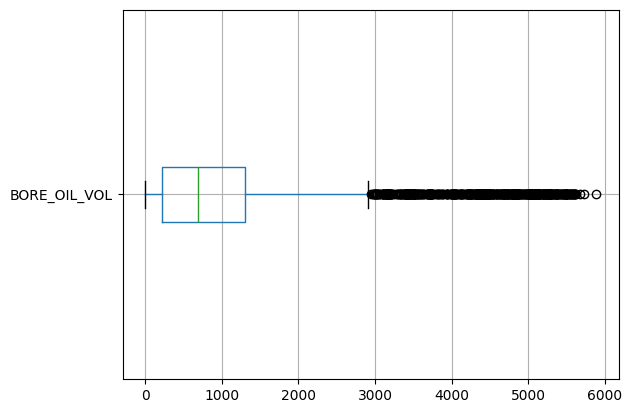

In [152]:
volve.boxplot(column=['BORE_OIL_VOL'], vert=False);

**Insight:** There are some outliers in our data. Therefore, here are several ways to handle outliers in Python:

Remember, the choice of approach depends on your specific goals and the nature of your data. By considering these different methods, you can decide how to handle outliers while prioritizing the retention of their valuable information for your model.

1. **Correct Value**: Correcting a data point to its proper value. Let's say you have a dataset that records the heights of individuals. The data is supposed to be in meters, but there was an error during data entry, and someone mistakenly input the values in centimeters. For instance, the height of a person is recorded as 170, which should be interpreted as 170 centimeters instead of the intended 170 meters. To correct this error and convert the height to the proper value in meters, you need to divide the recorded value by 100. In this case, the corrected height would be 1.70 meters.

2. **Remove Outliers**: One way to handle outliers is by selectively removing extreme values from the dataset. However, this method may result in a loss of data and potentially biased results.

3. **Replacing with Statistical Measures**: Instead of removing outliers, you can replace them with more representative values derived from statistical measures. Calculate the median or other robust statistical measures that are less sensitive to outliers, and use them as replacements for outliers while retaining the rest of the dataset unchanged. This method make them less extreme and this technique suitable for small datasets with numerous outliers that negatively impact the model's performance. But, care should be taken to consider the implications of modifying the original data!!!

4. **Keeping Outliers as They Are**: If you want to preserve the outliers without modifying them, you can simply do nothing. Leave the outliers as they are in the dataset, and include them in your analysis without any alterations. This approach acknowledges the rich information contained in outliers and allows your model to learn from their unique patterns.

Overall, by choosing to keep outliers as they are, you will more prioritize gaining rich information that can enhance your business insights and provide a more accurate representation of the underlying data distribution.

Reference: 

- [Best-Practice Recommendations for Defining, Identifying, and Handling Outliers](http://www.hermanaguinis.com/ORMoutliers.pdf)

- [How to Detect and Handle Outliers](https://hwbdocuments.env.nm.gov/Los%20Alamos%20National%20Labs/TA%2054/11587.pdf)

To identify outliers, there are some methods, such as

- **IQR method**: This method involves identifying the interquartile range (IQR) of the data and removing any values outside of a specified range. The IQR is defined as the difference between the third quartile (75th percentile) and the first quartile (25th percentile). Any value that is more than 1.5 times the IQR away from the quartiles is considered an outlier. 

- **Z-score method**: This method involves calculating the z-score of each data point, which measures how many standard deviations away from the mean the data point is. Any data point with a z-score greater than a specified threshold (e.g., 3) is considered an outlier. We can use the zscore function from the scipy.stats module to calculate the z-scores

In [153]:
Q1 = volve['BORE_OIL_VOL'].quantile(0.25)
Q3 = volve['BORE_OIL_VOL'].quantile(0.75)
IQR = Q3 - Q1

Q3 + 1.5 * IQR

2932.625

The values of `BORE_OIL_VOL` that we considered outliers are the values that is greater than 2932.625, therefore we will remove those values from our data.

In [154]:
volve = volve[volve['BORE_OIL_VOL'] < 2932.625]

## Least Squares Regression

One of the terms you’ll hear a lot in this course is **least squares**. So let’s try and achieve some intuition about this important concept through the following illustration. Lets create a histogram from our target data.

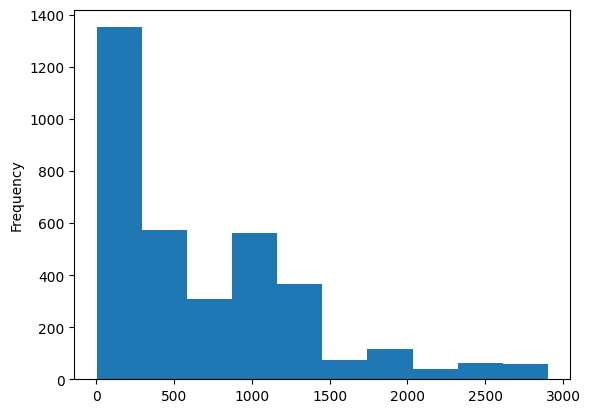

In [155]:
volve['BORE_OIL_VOL'].plot.hist();

The idea of a least squares estimate is to identify a point in our data that minimizes the sum of the squared distances between the observed data and itself. We’ll observe later that, with no predictor variables, this least squares estimate is the sample average.

Because our estimation model isn’t going to predict every observation perfectly, minimizing the average (which is equivalent to: the sum) of squared errors seem like a reasonable thing to do. If we had minimize the average absolute deviation between the data, it would lead us to the median as the least squares estimate instead of the mean. While this may seem intuitive to some, I am counting on some of you to be skeptical enough as to question me on whether the sample average would in fact lead us to the least squares estimate.

Let’s discuss the importance of least squares in the context of regression models. We will use the `AVG_WHP_P` or the well head pressure column as an example.

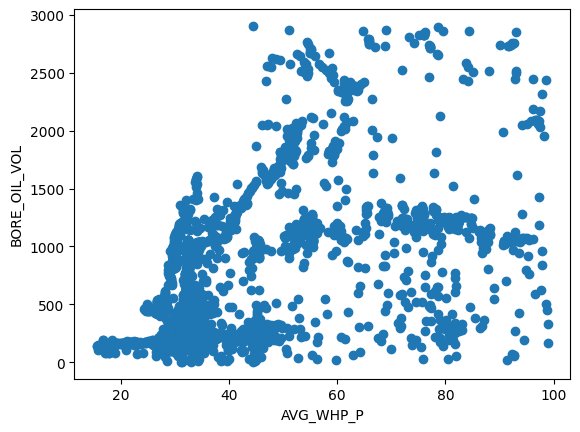

In [156]:
plt.scatter(volve['AVG_WHP_P'], volve['BORE_OIL_VOL'])
plt.xlabel('AVG_WHP_P')
plt.ylabel('BORE_OIL_VOL');

In [157]:
volve[['AVG_WHP_P', 'BORE_OIL_VOL']].corr()

,AVG_WHP_P,BORE_OIL_VOL
AVG_WHP_P,1.00,0.55
BORE_OIL_VOL,0.55,1.00


We can see a fairly linear relationship between the `BORE_OIL_VOL` and `AVG_WHP_P` columns of our `volve` dataset, and the objective of a simple linear regression is concerned with modeling that relationship with a straight line.

## Simple Linear Regression

Create a linear model in Python is as convenient as you’d wish it to be. We will call the `OLS()` function from `statsmodels` library and specify two parameters: "Y" or the response/target variable, and "X" for the predictors:

In [158]:
import statsmodels.api as sm

Y = volve['BORE_OIL_VOL']
X = sm.add_constant(volve['AVG_WHP_P'])

# fit the model
lm = sm.OLS(Y, X).fit()
lm.params

const       -115.74
AVG_WHP_P     19.61
dtype: float64

*__Note__: *Without sm.add_constant, `statsmodels` algorithms assume that $β_0 = 0$ in $\hat Y=β_0+β_1X_1$, and it'll fit the model using $β_0 = 0$ instead of calculating what β_0 is supposed to be based on your data. Please go through the next explanation for further explanation about the formula*

The `lm.params` return the coefficients of our linear model. But, now that we have the coefficients, what does that tell us? The size of the coefficients tell us the effect that variable has on our target variable. . From the coefficient we can acknowledge that:

- A positive coefficient will indicate that the effect is positive: the higher the wellhead pressure, the higher the oil production. 
- A negative coefficient will indicate the opposite: the higher the wellhead pressure, the lower the oil production. 

Since `AVG_WHP_P` have a coefficient of $19.61$ on `BORE_OIL_VOL` it is a positive number we know that the effect is positive.

In addition to the above information, we’ve also derived the profit equation from our linear model directly. It takes the form:

$\hat Y=β_0+β_1X_1$

Which means:  

```
BORE_OIL_VOL = Intercept + Slope * AVG_WHP_P
```

Substituting the beta coefficients into the formula hence yield:  

```
BORE_OIL_VOL = -117.66 + 23.01 * AVG_WHP_P
```

That tells us that the `BORE_OIL_VOL` is expected to increase by $19.61$ barrels when the `AVG_WHP_P` of the wellbore increased by $1$ percent, and decrease by $19.61$ barrels when the `AVG_WHP_P` decreased by $1$ percent.

`statsmodels` has functions such as `*.predict()` that allow us to obtain predictions given some input data. predict expects a machine learning model as its first parameter, and in this case a data frame to predict on:

Supposed we’re expecting an oil production with a wellbore with an average setting of 100% wellhead pressure. What would our linear model predict its oil volume to be?

In [159]:
AVG_WHP_P=[1, 100]
lm.predict(AVG_WHP_P)

array([1845.36958171])

In [160]:
lm.predict(X)

#equivalent with:
lm.fittedvalues

5      1804.13
6      1693.21
8      1793.77
9      1808.54
21     1711.01
         ...  
4103    413.74
4104    412.87
4105    411.83
4106    411.21
4107    422.88
Length: 3507, dtype: float64

And with that let’s create our plot again, but this time we’ll also add a line from the result of our linear model prediction:

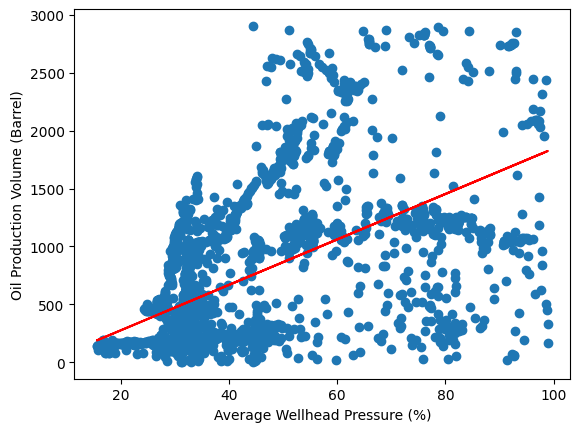

In [161]:
plt.scatter(volve['AVG_WHP_P'], volve['BORE_OIL_VOL'])
plt.plot(volve['AVG_WHP_P'], lm.fittedvalues, c='r')

plt.xlabel('Average Wellhead Pressure (%)')
plt.ylabel('Oil Production Volume (Barrel)');

That line, it turns out, is the line of best fit for our observations. This fitted line is estimated with error because the points are not perfectly predicted by the line (even though they hover around the line), and our linear model `lm` have estimated this line to minimize the **least squares error**.

Because of how common the `(actual-estimation)**2).sum()` calculation is, we gave it a name: **sum of squared errors**, which is literal and memorable. OLS’s `.resid` attribute allows us to compute the difference between the predicted and actual values:

In [162]:
((lm.resid)**2).sum()

932138194.6403792

When I said “estimating a line”, I hope it occurs to you that we’re in fact estimating **two parameters**: the point at which our line cross the y-axis (known as the “intercept” term) and the slope degree (known as the “slope”). Collectively they’re also referred to as **coefficients** (or “beta coefficients”), but really you should know they mean the same thing. 

For most machine learning models we created in `statsmodels`, we can use functions such as `summary()` to obtain more information about the model. Let’s try and apply it on the model we just created:

In [163]:
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           BORE_OIL_VOL   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.298
Method:                 Least Squares   F-statistic:                     1490.
Date:                Thu, 16 May 2024   Prob (F-statistic):          6.38e-272
Time:                        17:06:06   Log-Likelihood:                -26878.
No. Observations:                3507   AIC:                         5.376e+04
Df Residuals:                    3505   BIC:                         5.377e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -115.7450     22.974     -5.038      0.000    -160.789     -70.701
AVG_WHP_P     19.6111      0.508     38.598      0.000      18.615      20.607
==============================================================================
Omnibus:                      322.049   Durbin-Watson:                   1.264
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              473.128
Skew:                           0.711   Prob(JB):                    1.83e-103
Kurtosis:                       4.102   Cond. No.                         119.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

For now, let's focus on the second table of the model `summary()` above :

In [164]:
lm.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,-115.7450,22.974,-5.038,0.000,-160.789,-70.701
AVG_WHP_P,19.6111,0.508,38.598,0.000,18.615,20.607


- From the output above, we see the two coefficients that represent our regression line in y-intercept (`const`) and slope (`AVG_WHP_P`). The point at which our line crosses the y-intercept is -117.6566 and the slope is 23.0129. The coefficient of the slope is estimated so as to minimize the vertical distance between the observed points (truth) and the prediction. 
- The standard error (`std err`) that was printed is an estimate of the standard deviation of the coefficient, which, recall, is an indication of how much our estimate varies across samples (due to random sampling). The lower it is, the higher is the level of accuracy of the coefficients.
- The t-value (`t`) we obtain from the summary is just the coefficient divided by the standard error:

In [165]:
19.6111/0.508

38.60452755905512

- P-value (`P>|t|`) give us a probability of obtaining a t-value as extreme as what we just observed. P-value lower than 0.05 indicates that the predictor is statistically significant to the model.
- Confidence Interval (`[0.025   0.975]`) represents the range in which our coefficients are likely to fall (with a likelihood of 95%)

The reason why we’re concerned with these statistics is that in the regression modeling, we’re trying to investigate if there’s sufficient evidence that our independent variables (or “predictor variables”) are different from 0. That is to say, we like to know if variables like sales, branch ID, or time of day have any real effect on the profitability of our Profit, or if variables such as humidity level, temperature, or duration of outdoor exposure has any real effect on machinery corrosion level.

Through a regression model, we want to see if these variables are genuinely affecting the target variable (`BORE_OIL_VOL`) or that any apparent differences in volume are just due to random chance and sampling; The null hypothesis, recall, is that the reason we observe a difference in daily oil production volume, is ultimately due to random chance from sampling - if we have sampled a different number of months, we would have observed a completely or even contradictory scenario! Recall from our practical statistics class that the rule of thumb to reject the null hypothesis (no effect) and favor the alternative hypothesis is 0.05. That is, if the chance of us observing a profit distribution such as these provided that they are in fact independent from store branches is only 5%, then we’d reject the null hypothesis.

*__Note__: If you need a refresher on the statistical concepts I’ve mentioned above, I encourage you to quickly glance over the Practical Statistics coursebook again and do some revision with your assigned academic mentor. If you’d like an in-depth treatment of the subject, I can recommend the free PDF copy of [The Elements of Statistical Learning: Data Mining, Inference, and Prediction](https://web.stanford.edu/~hastie/ElemStatLearn/download.html)*

## R-Squared

Now let's take a look again to the first table of our model's `summary()`:

In [166]:
lm.summary().tables[0]

Dep. Variable:,BORE_OIL_VOL,R-squared:,0.298
Model:,OLS,Adj. R-squared:,0.298
Method:,Least Squares,F-statistic:,1490.
Date:,"Thu, 16 May 2024",Prob (F-statistic):,6.38e-272
Time:,17:06:06,Log-Likelihood:,-26878.
No. Observations:,3507,AIC:,5.376e+04
Df Residuals:,3505,BIC:,5.377e+04
Df Model:,1,,
Covariance Type:,nonrobust,,


Notice on the upper right, you'll see it return the information of the model's **R-squared**. R squared by definition is the percentage of the total variability that is explained by the linear relationship with the predictor (Regression Variation / Total Variation):

$R^2=1- \frac {∑ \limits_{i=1}^n (Y_i−\hat Y)^2}{∑ \limits_{i=1}^n(Y_i−\bar Y)^2}$

In other words, R squared can be thought of as a quantity that represents the % of the total variation that’s represented by the model. We simply take the regression variation and divide it by the total variation. In our case, it is the % of the variation in oil volume that is explained by the regression relationship with the average wellhead pressure. Some facts about $R^2$:
- $R^2$ is the percentage of variation explained by the regression model
- 0 ≤ $R^2$ ≤ 1
- If we define R as the sample correlation between the predictor and the outcome, $R^2$ is simply the sample correlation squared

Because R-squared is a statistical measure of how close the data are to the fitted line, we want our model to achieve a high R-squared as it means our model has fit the data well (not always the case, but we’ll get to that later). You can also retrieve the information of the model R-squared by accessing the `.rsquared` attribute:

In [167]:
lm.rsquared

0.2982703991467759

## Leverage vs. Influence

Recall earlier that we left out the outlying data point; To illustrate the idea of leverage and power we’ll load a new `volve` dataset with the original data read from our csv again.

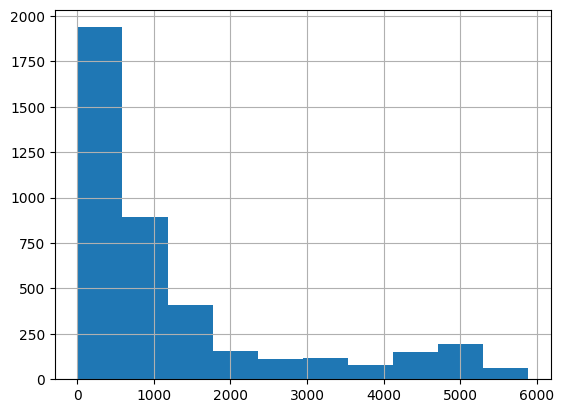

In [168]:
volve_outlier = pd.read_csv('data_input/volve_field.csv')
volve_outlier['BORE_OIL_VOL'].hist();

Now let’s create a linear model named `lm_outlier` and plot the regression line:

In [169]:
X_outlier = sm.add_constant(volve_outlier['AVG_WHP_P'])
Y_outlier = volve_outlier['BORE_OIL_VOL']

lm_outlier = sm.OLS(Y_outlier, X_outlier).fit()

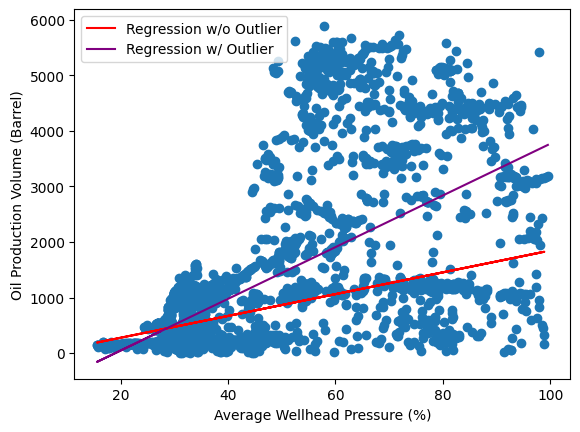

In [170]:
plt.scatter(volve_outlier['AVG_WHP_P'], volve_outlier['BORE_OIL_VOL'])

plt.plot(volve['AVG_WHP_P'], lm.fittedvalues, c='red', label='Regression w/o Outlier')
plt.plot(volve_outlier['AVG_WHP_P'], lm_outlier.fittedvalues, c='purple', label='Regression w/ Outlier')

plt.xlabel('Average Wellhead Pressure (%)')
plt.ylabel('Oil Production Volume (Barrel)')
plt.legend(loc="upper left");

Notice the presence of that outlier have influenced our regression line. Let’s inspect the impact our outlier data point has had on our model by printing the coefficients and rsquared of this model with our outlier-exempted model:

In [171]:
print(lm.params)
print(lm.rsquared)

print(lm_outlier.params)
print(lm_outlier.rsquared)

const       -115.74
AVG_WHP_P     19.61
dtype: float64
0.2982703991467759
const       -884.68
AVG_WHP_P     46.52
dtype: float64
0.3781476078175643


Our outlier there is said to have **high leverage** if it’s predictor value (x-axis) is far away from the mean of the predictor values for all observations. In other words, if a point is far away from where the rest of the data, we say that the point has high leverage. This point has the potential to greatly influence the coefficients of our regression model, but we have yet to establish whether it did. Supposed that the point with high leverage is positioned in a way that largely fits the pattern observed in the rest of the data, then it is not particularly influential.

However, another outlier point that share the same leverage (its x-value is equally distant from the mean of the other observations) may substantially decreased the R-squared, and we can observe from the coefficients that the inclusion of this outlier has strong influence on our coefficients.

As a data scientist, it is important we learn to recognize when our regression models are unduly influenced by rare but influential data points - the inclusion of one or more influential outliers could strongly bias our regression model and render our analysis null.

# Multiple Linear Regression

Earlier on, we predict a future value of y given one input, x. Recall the y in our first example is the `BORE_OIL_VOL` and our x is the `AVG_WHP_P`. 

Also recall that because the `BORE_OIL_VOL` depend on the `AVG_WHP_P`, this y we’re working with is often referred to as dependent variable while the x are referred to as, you guessed it, independent variables. Can a regression model contain more than one dependent variable? Absolutely! Lets create a regression model using all of the other columns except `DATE_PERIOD` as our predictors. The `DATE_PERIOD` column doesn't hold relevant information that would help the model to learn.

In [172]:
Y = volve['BORE_OIL_VOL']
X = sm.add_constant(volve.drop(columns=['BORE_OIL_VOL', 'DATE_PERIOD']))

# fit the model
lm_multiple = sm.OLS(Y, X).fit()
lm_multiple.params

const                          -2873.19
ON_STREAM_HRS                     27.95
AVG_DOWNHOLE_PRESSURE            770.22
AVG_DOWNHOLE_TEMPERATURE          44.01
AVG_DP_TUBING                   -786.29
AVG_ANNULUS_PRESS                 -0.52
AVG_CHOKE_SIZE_P                  -0.03
AVG_WHP_P                       -768.01
AVG_WHT_P                         20.42
NPD_WELL_BORE_NAME_15/9-F-12    1092.21
NPD_WELL_BORE_NAME_15/9-F-14      67.96
NPD_WELL_BORE_NAME_15/9-F-15    -305.17
dtype: float64

Notice that now we have predictor variables of numeric and categorical data types. Previously in Simple Linear Regression we learned how to interpret regression coefficients from predictors of numerical data type. What about the interpretation of regression coefficients from predictors of categorical data type? Is there a difference with variables with numeric data type? 

Interpretation of the coefficient value of a categorical variable shows an increase/decrease in the target value when they are being compared to the basis category. Note that the values of other predictors are also constant. For example, in the `NPD_WELL_BORE_NAME` variable, the basis category is the wellbore `15/9-F-11`. Notice that the coefficient of wellbore `15/9-F-12` is 1092.21, it means that if volve used the `15/9-F-12` wellbore, the oil volume will be increased by 1092.21 barrels compared if volve used the `15/9-F-11` wellbore.

## Adjusted R-Squared

Using R-squared itself can be misleading in our assessment of the model fit and this is due to the one of the key limitation of this metric. R-squared, it turns out increases with every new addition of a predictor variable, even if it turns out that the variable is just completely random number - the R-squared does not decrease. As a result, a model with more independent variables may appear to have a better fit just on the merit of having more terms alone.

A model that has too many predictors also tend to overfit and worse, the regression model would “model” the random noise in our data as if they were “features”, hence producing misleading R-squared values.

The adjusted R-squared compares the explanatory power of regression models built with different number of predictors, allowing us to compare a crime rate regression model with 4 variables to another one with just 2 variables and find out if the one with 4 has achieved a higher R-squared simply because it has more predictors or if they truly lead to a better fit.

Compare the following 3 models and pay attention to both it’s R-squared and Adjusted R-squared values:

In [173]:
Y = volve['BORE_OIL_VOL']

# model 1
X_model1 = sm.add_constant(volve['AVG_WHP_P'])
model1 = sm.OLS(Y, X_model1).fit()

# model 2
X_model2 = sm.add_constant(volve[['AVG_WHP_P','ON_STREAM_HRS', 'AVG_DOWNHOLE_PRESSURE']])
model2 = sm.OLS(Y, X_model2).fit()

# model 3
X_model3 = sm.add_constant(volve[['AVG_WHP_P','ON_STREAM_HRS','AVG_DOWNHOLE_PRESSURE','AVG_DOWNHOLE_TEMPERATURE', 'AVG_WHT_P']])
model3 = sm.OLS(Y, X_model3).fit()

pd.set_option('display.float_format', lambda x: '%.4f' % x) # pandas output
# compare result
pd.DataFrame({
    'model': ['model1', 'model2', 'model3'],
    'r-squared': [model1.rsquared, model2.rsquared, model3.rsquared],
    'adj. r-squared': [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj]
})

,model,r-squared,adj. r-squared
0,model1,0.2983,0.2981
1,model2,0.3579,0.3573
2,model3,0.7728,0.7725


`model1` has one predictor variable and has an R-squared of 0.2983 (adjusted R-squared of 0.2981). We see that by adding 4 additional predictors (`ON_STREAM_HRS`, `AVG_DOWNHOLE_PRESSURE`, `AVG_DOWNHOLE_TEMPERATURE`, `AVG_WHT_P`) the R-squared of our model increased to 0.7728	(`model3`). 

Adjusted R-squared on the other hand does not increases the way R-squared does because it is adjusted for the number of predictor variables in our model. It increases only when the new variable actually leads to a better prediction. While the mathematical details of the adjusted R-squared formula is beyond the scope of this workshop, I'll give you a quick proof that it does "penalizes" the r-squared based on the number of predictors the model contains.

The mathematical notation of adjusted R-squared:

$R^2_{adj} = 1-(1-R^2)\frac{n-1}{n-p-1}$

Where _n_ is the number of observations and _p_ is the number of predictors. Notice that as _p_ increases, the second term becomes larger and pushing the overall adjusted R-squared value down. If it isn't obvious, I included the following code so you can play around by changing the number of predictors (we used 5 in the model):

In [174]:
model3.rsquared

0.7728320536536952

In [175]:
no_of_preds = 5
adjusted_model3 = 1 - (1-model3.rsquared)  * (volve.shape[0]-1) / (volve.shape[0]-1-no_of_preds)

adjusted_model3

0.7725076207111841

# Regression Model Evaluation

In some cases, you might end up with more than one model for you to choose. It is often important for us to evaluate the performance of each model to find out which of the models result in the least total error. On the next chapters of machine learning specialization, we will dwell into an in-depth discussion on various evaluation metrics. A rather common measure we'll introduce in this chapter is Root Mean Squared Error. It measures the root mean square of observed data points to its predicted values. The mathematical notation of RMSE:

$RMSE = \sqrt{\frac{\sum_i^{n}(Predicted_i-Actual_i)^2}{n}}$



`statsmodels` has the `rmse` function that can be used to calculate the RMSE value:

In [176]:
from statsmodels.tools.eval_measures import rmse

# predict data with different models
y_model1 = model1.predict(X_model1)
y_model2 = model2.predict(X_model2)
y_model3 = model3.predict(X_model3)
y_multiple = lm_multiple.predict(X)

# compare the rmse
pd.DataFrame({'RMSE': [rmse(Y, y_model1), rmse(Y, y_model2), rmse(Y, y_model3), rmse(Y, y_multiple)]},
             index= ['Model 1', 'Model 2', 'Model 3', 'Model All'])

,RMSE
Model 1,515.5518
Model 2,493.1735
Model 3,293.3330
Model All,204.4819


#  Limitations of Regression Models

Linear regression models, even when considered to be the powerhouse of statistics came with its limitations and assumptions.

- Linear regressions are best fitted on data where a linear relationship between the predictor variables and target exist.   
- Simple / Multiple regression models can be sensitive to outliers (recall the chapter regarding leverage and power)  
- Simple / Multiple regression models assumes that the independent variables are not highly correlated with each other

In making predictions on the target variable using linear regression, **we must fulfill several assumptions as a condition that the regression model that we make is statistically appropriate**.
Some of the assumptions that must be fulfilled in linear regression models are:

1. Linear prediction variables for target variables
2. Normal residuals
3. Residuals have no heteroscedasticity
4. There is no multicollinearity


In fact,to check these assumptions, our model `summary()` [provides several measures](https://www.statsmodels.org/dev/examples/notebooks/generated/regression_diagnostics.html) to give you an idea of the distribution and behavior. Take a look at the bottom part of our model summary:

In [177]:
lm_multiple.summary().tables[2]

Omnibus:,537.704,Durbin-Watson:,1.290
Prob(Omnibus):,0.000,Jarque-Bera (JB):,8103.420
Skew:,-0.179,Prob(JB):,0.00
Kurtosis:,10.438,Cond. No.,1.17e+06


## Normality of Residuals

Recall that residuals is the difference between the observed data and the fitted values. The normality assumption means that the residuals from the linear regression model should be normally distributed because we expect to get residuals near the zero value. To check whether the residuals of our model is normal, there are multiple statistics test that can check for normality, among the common ones are Shapiro-Wilk test. 

In the test we use hypothesis testing if check our model has normal residual:
- $H_0$ : residuals model normal  
- $H_1$ : residuals model is not normal  

>Recall our practical statistics material, if we want to get our conclusion of model has normal of residual, we must get the p-value of test bigger than alpha (5%).

In [178]:
from scipy.stats import shapiro

name = {0: 'Statistics',1: 'p-value'}
pd.DataFrame({shapiro(lm_multiple.resid)}).rename(columns=name)

,statistic,pvalue
0,0.9126,0.0000


Since we arrived at p-value of ≈ 0, smaller than our alpha, means that we reject null hypothesis and our residual is not following a normal distribution. However, a certain notes from the official documentation we should take note of:

> For N > 5000 the W test statistic is accurate but the p-value may not be.

In this case, we must be aware of the limitation and use additional methods to verify our results such as visually inspecting data distribution.

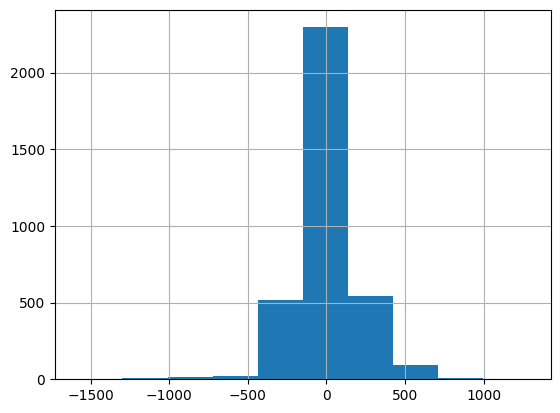

In [179]:
lm_multiple.resid.hist();

### [Optional:] Interpret the Residual Normality Indicators from `sm` results

You can also use the model summary to inspect the normality of the residuals from the listed values:

- **Omnibus/Prob(Omnibus)** – a test of the skewness and kurtosis of the residual.A value close to 0 indicates normality. The Prob (Omnibus) performs a statistical test on the probability of the residuals are normally distributed.A value close to 1 indicates the probability that the residuals are normally distributed. 

- **Skew** – measures data symmetry. A value close to 0 indicates the residual distribution is normal

- **Jarque-Bera/Prob(JB)** – A value of 6 or higher indicates that errors are not normally distributed and the normality null hypothesis has been rejected at the 5% significance level. A value close to 0 indicates the data is normally distributed. 


In [180]:
lm_multiple.summary().tables[2]

Omnibus:,537.704,Durbin-Watson:,1.290
Prob(Omnibus):,0.000,Jarque-Bera (JB):,8103.420
Skew:,-0.179,Prob(JB):,0.00
Kurtosis:,10.438,Cond. No.,1.17e+06


## No-Heteroscedasticity

Similar to normality residual test, the residual we have must be homogeneous which means the data is spread. If the residual data that we have spreads and does not form a pattern, the linear regression model that we have is sufficiently explain our data. 

A residual plot is a plot that plot the residual values on the y-axis and the fitted values on the x-axis. Once we’ve done that, we look for any unwanted patterns in the plot that may indicate a violation in model assumptions particularly relating to incorrect specifications.

A residual plot that has points randomly scattered around the x-axis is the one we want. It doesn’t mean that the model is perfect, but it does mean that the regression model you fit appropriately describes the variability in our dependent variable. If there is a pattern in the residual plot, it means that the model can be further improved upon or that it does not meet the linearity assumption:


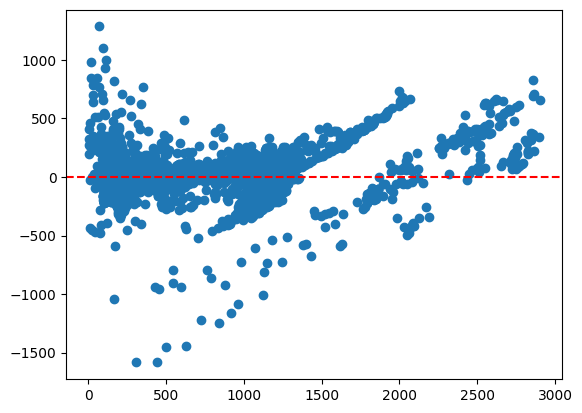

In [181]:
plt.scatter(x = volve['BORE_OIL_VOL'], y = lm_multiple.resid)
plt.axhline(y=0, color='r', linestyle='--');

To check our residuals doesn't have pattern, we can make a scatterplot between residual data and target variable or we can use Breuch-Pagan test.

In Breuch-Pagan test we have hypothesis that :

- $H_0$ : residuals model doesn't have pattern (homoscedasticity)
- $H_1$ : residuals model have pattern (heteroscedasticity)

> Recall our practical statistics material, if we want to get our conclusion of model has no heteroscedasticity, we must get the p-value of test bigger than alpha (5%)

We can use Breush-Pagan test from `het_breuschpagan()` function from `statsmodels`:

In [182]:
import statsmodels.stats.api as sms

name = {0: 'Lagrange multiplier statistic',
        1: 'p-value',
        2: 'f-value',
        3: 'f p-value'}

pd.DataFrame({
    sms.het_breuschpagan(lm_multiple.resid, lm_multiple.model.exog)
}).rename(columns= name)

,Lagrange multiplier statistic,p-value,f-value,f p-value
0,970.7443,0.0000,121.6092,0.0000


Since we arrived at p-value of ≈ 0, smaller than our alpha, we reject the null hypothesis. Which indicates that the model residuals do not have a random pattern (heteroscedasticity).

## No Multicolinearity

In linear mathematical formulation, we assumed that there are no correlation between the variables in order to have a separate independent effect of each variables. One of the statistical tool you have at your disposal when assessing multicollinearity is the **Variance Inflation Factor** (VIF) statistic. Put simply, VIF is a way to measure the effect of multicollinearity among the predictors in our model.

In [183]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

x = volve[['AVG_WHP_P','ON_STREAM_HRS','AVG_DOWNHOLE_PRESSURE','AVG_DOWNHOLE_TEMPERATURE', 'AVG_WHT_P']]
xc = sm.add_constant(x)

VIF = [vif(xc.values, i) for i in range(len(xc.columns))]
pd.Series(data=VIF, index=xc.columns)

const                      1735.0511
AVG_WHP_P                     1.5194
ON_STREAM_HRS                 1.1054
AVG_DOWNHOLE_PRESSURE         2.4776
AVG_DOWNHOLE_TEMPERATURE      1.7233
AVG_WHT_P                     2.6620
dtype: float64

The limitations of the different machine learning models are something we will revisit soon and again as we progress in the machine learning specialization. Not only will we learn how to identify them early - we’ll also learn various techniques to treat them, preventing overfitting / underfitting and making model diagnostic a critical part of your machine learning toolset.